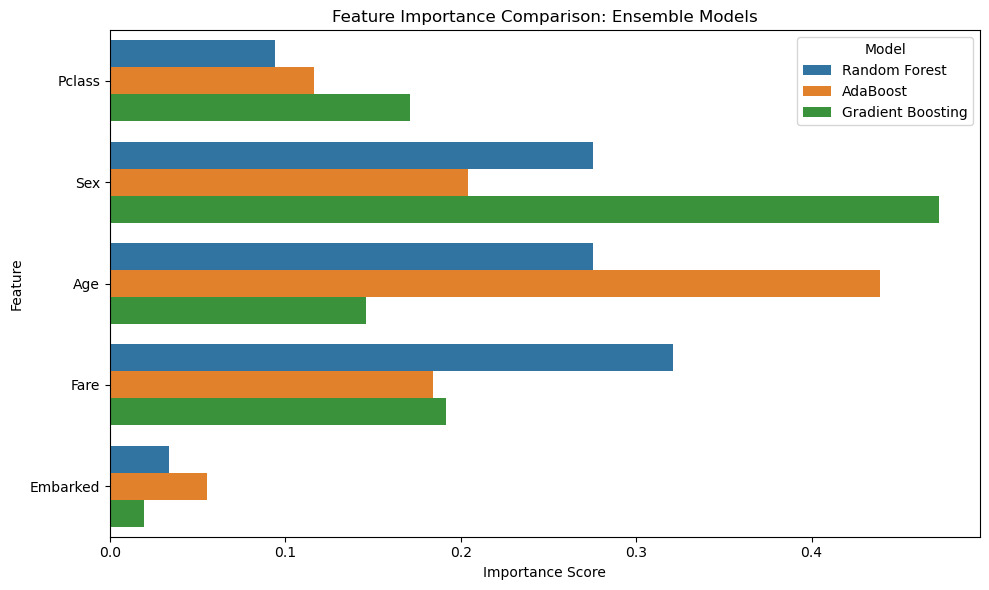

In [7]:
# Visualize feature importance from different ensemble models and discuss impact on predictions.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# ------------------------------------------
# Step 1: Load Titanic dataset
# ------------------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ------------------------------------------
# Step 2: Select important features + target
# ------------------------------------------
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# ------------------------------------------
# Step 3: Clean missing values
# ------------------------------------------
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# ------------------------------------------
# Step 4: Encode categorical features
# ------------------------------------------
for col in ['Sex', 'Embarked']:
    df[col] = LabelEncoder().fit_transform(df[col])

# ------------------------------------------
# Step 5: Feature matrix + target
# ------------------------------------------
X = df[features]
y = df['Survived']

# ------------------------------------------
# Step 6: Train/Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# Step 7: Initialize ensemble classifiers
# ------------------------------------------
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# ------------------------------------------
# Step 8: Collect feature importance
# ------------------------------------------
importance_df = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        temp = pd.DataFrame({
            'Feature': features,
            'Importance': importances,
            'Model': name
        })

        importance_df = pd.concat([importance_df, temp], ignore_index=True)

# ------------------------------------------
# Step 9: Plot comparison of feature importance
# ------------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Model'
)

plt.title("Feature Importance Comparison: Ensemble Models")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_comparison.png")
plt.show()
